In [24]:
import joblib
best_model = joblib.load('best_model.pkl')
s = joblib.load('scaler.pkl')

c:\Users\MSI\ML-final-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



📊 Feature Profile (% of valid range):
  Feature                         Value        %  Bar
  -----------------------------------------------------------------
  Diet_Quality                     3.00    66.7%  █████████████
  Employment                       0.00     0.0%  
  Stress_Level                     5.00    43.8%  ████████
  Total_Productive_Hrs             8.00    50.0%  ██████████
  Distraction_Hrs                  2.00    15.8%  ███
  Study_Distraction_Ratio          2.50    30.0%  ██████
  Wellbeing_Score                  6.00    71.9%  ██████████████
  Active_Engagement_Score         10.50    62.5%  ████████████
  Study_Quality                   15.00    83.3%  ████████████████
  AI_Enhanced_Study               15.00    62.5%  ████████████
  Resource_Quality                10.00    60.0%  ████████████
  Focus_Ratio                      4.00    20.0%  ████
  Stress_Wellbeing                 0.30     1.1%  
  AI_Engagement                   45.00    83.3%  ████████████████

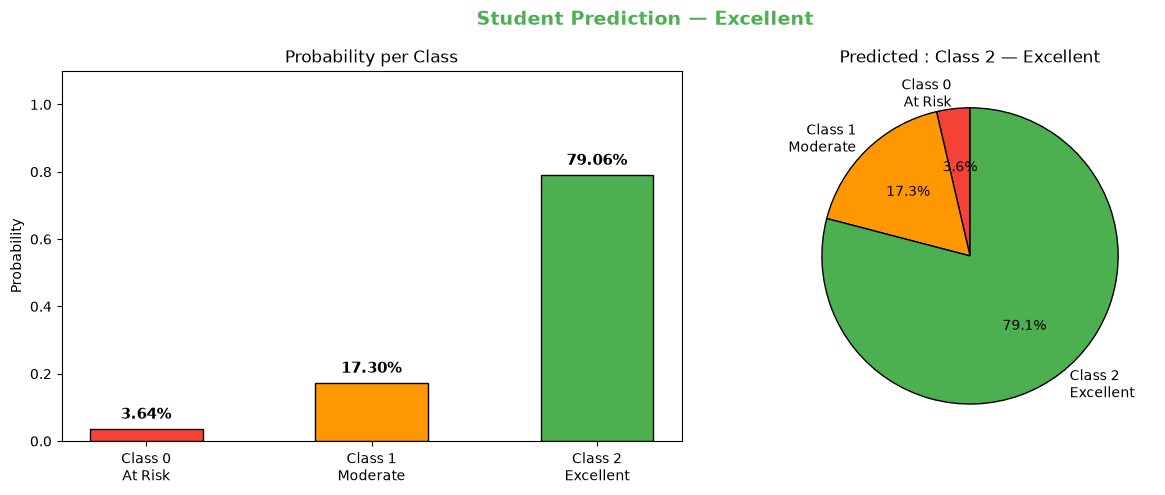

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Feature valid ranges (min, max) from dataset ─────────────────────────────
feature_ranges = {
    "Diet_Quality"            : (1.0,   4.0),
    "Employment"              : (0.0,   2.0),
    "Stress_Level"            : (1.5,   9.5),
    "Total_Productive_Hrs"    : (0.0,  16.0),
    "Distraction_Hrs"         : (0.5,  10.0),
    "Study_Distraction_Ratio" : (0.0,   8.33),
    "Wellbeing_Score"         : (-5.5, 10.5),
    "Active_Engagement_Score" : (5.5,  13.5),
    "Study_Quality"           : (0.0,  18.0),
    "AI_Enhanced_Study"       : (0.0,  24.0),
    "Resource_Quality"        : (1.0,  16.0),
    "Focus_Ratio"             : (0.0,  20.0),
    "Stress_Wellbeing"        : (0.09, 19.0),
    "AI_Engagement"           : (0.0,  54.0),
    "Lifestyle_Index"         : (0.17,  0.97),
    "Study_Consistency"       : (0.0,   9.0),
    "Time_Efficiency"         : (0.0,   7.2),
    "Digital_Balance"         : (0.0,   6.67),
    "Academic_Momentum"       : (5.5,  40.5),
    "Stress_Load"             : (2.44, 96.19),
}

# ── Tier thresholds derived from dataset means ────────────────────────────────
FEATURE_ADVICE = {
    "Diet_Quality": (
        "Diet Quality", 2.74, 2.05, "up", "",
        "Great diet habits — keep it up for sustained focus and energy.",
        "Poor diet is linked to lower cognitive performance. Aim for at least 3 balanced meals a day."
    ),
    "Employment": (
        "Employment Hours", 0.36, 0.76, "down", "hrs",
        "Part-time work is manageable if you protect study blocks.",
        "High work load is eating into study time. Consider reducing shifts during exam season."
    ),
    "Stress_Level": (
        "Stress Level", 5.69, 6.85, "down", "/10",
        "Stress is well-managed — maintain your current coping strategies.",
        "Dangerously high stress. Try time-boxing tasks, short breaks (Pomodoro), and sleep hygiene."
    ),
    "Total_Productive_Hrs": (
        "Productive Hours / Week", 5.14, 2.76, "up", "hrs",
        "Good productive hours. Protecting this time is key to your performance.",
        "Very low productive hours. Block 2-hr deep-work slots daily with phone out of reach."
    ),
    "Distraction_Hrs": (
        "Distraction Hours / Week", 3.39, 5.96, "down", "hrs",
        "Distraction is under control — stay disciplined.",
        "Too many hours lost to distractions. Use app blockers (Forest, Cold Turkey) during study."
    ),
    "Study_Distraction_Ratio": (
        "Study : Distraction Ratio", 1.32, 0.34, "up", "",
        "Solid focus ratio. Continue prioritising quality study time.",
        "Spending nearly as much time distracted as studying. Restructure your daily schedule."
    ),
    "Wellbeing_Score": (
        "Wellbeing Score", 3.27, 0.29, "up", "",
        "Wellbeing is healthy — keep investing in rest and social support.",
        "Very low wellbeing. Speak to a counsellor or trusted peer; burnout risks performance long-term."
    ),
    "Active_Engagement_Score": (
        "Active Engagement", 11.51, 8.68, "up", "",
        "High engagement is a strong predictor of success — keep participating actively.",
        "Low class/study engagement. Try active recall, group study, or office-hour visits."
    ),
    "Study_Quality": (
        "Study Quality", 7.73, 2.69, "up", "",
        "Strong study quality. Maintain varied, spaced-repetition techniques.",
        "Study quality is low. Move from passive re-reading to practice problems and self-testing."
    ),
    "AI_Enhanced_Study": (
        "AI-Enhanced Study", 9.79, 4.55, "up", "",
        "Good AI tool integration. Keep using them critically, not as a crutch.",
        "Under-utilising AI study tools. Try Claude, ChatGPT, or Khanmigo for concept explanations."
    ),
    "Resource_Quality": (
        "Resource Quality", 7.40, 4.39, "up", "",
        "Access to quality resources is strong.",
        "Resource quality is weak. Visit your library, ask instructors for reading lists, use Khan Academy."
    ),
    "Focus_Ratio": (
        "Focus Ratio", 2.11, 0.53, "up", "",
        "Good focus ratio — guard this with consistent sleep and environment.",
        "Focus ratio is critically low. Study in a quiet, dedicated space and reduce multitasking."
    ),
    "Stress_Wellbeing": (
        "Stress-to-Wellbeing Ratio", 0.75, 1.83, "down", "",
        "Stress is balanced relative to wellbeing.",
        "Stress far outweighs wellbeing. Prioritise recovery: sleep, exercise, social connection."
    ),
    "AI_Engagement": (
        "AI Engagement", 35.72, 21.91, "up", "",
        "Strong AI engagement score.",
        "Low AI engagement. Integrate AI tools into weekly study habits for explanations and feedback."
    ),
    "Lifestyle_Index": (
        "Lifestyle Index", 0.56, 0.40, "up", "",
        "Healthy lifestyle balance.",
        "Lifestyle index is poor. Small wins count: 30-min walks, 7-8 hrs sleep, meal prepping."
    ),
    "Study_Consistency": (
        "Study Consistency", 4.19, 1.63, "up", "",
        "Consistent study schedule — this is one of the biggest performance drivers.",
        "Irregular study pattern. Create a weekly timetable and treat study blocks like class time."
    ),
    "Time_Efficiency": (
        "Time Efficiency", 1.29, 0.39, "up", "",
        "High time efficiency — you're getting good output per hour.",
        "Low time efficiency. Review HOW you study, not just how long. Active methods beat passive ones."
    ),
    "Digital_Balance": (
        "Digital Balance", 1.25, 0.52, "up", "",
        "Good digital balance.",
        "Digital balance is off. Track screen time, set app limits, keep devices out of the bedroom."
    ),
    "Academic_Momentum": (
        "Academic Momentum", 27.75, 13.87, "up", "",
        "Strong academic momentum — you're building on consistent effort.",
        "Academic momentum is stalling. Break goals into weekly milestones to rebuild progress."
    ),
    "Stress_Load": (
        "Stress Load", 21.90, 45.46, "down", "",
        "Stress load is manageable.",
        "Extremely high stress load. Identify the top 2-3 stressors and tackle them one at a time."
    ),
}


def softmax_with_temp(probs, temperature=3.0):
    logits = np.log(np.clip(probs, 1e-9, 1)) / temperature
    e = np.exp(logits - np.max(logits))
    return e / e.sum()


def print_feature_profile(student: dict):
    print("\n📊 Feature Profile (% of valid range):")
    print(f"  {'Feature':<28} {'Value':>8}   {'%':>6}  Bar")
    print("  " + "-"*65)
    for feat, val in student.items():
        lo, hi = feature_ranges[feat]
        pct = (val - lo) / (hi - lo) * 100
        pct = max(0.0, min(100.0, pct))
        bar = "█" * int(pct / 5)
        print(f"  {feat:<28} {val:>8.2f}   {pct:5.1f}%  {bar}")


def generate_recommendations(student: dict, predicted_tier: int, probabilities: dict) -> list:
    messages = []

    if predicted_tier == 0:
        messages.append("🔴 ALERT — This student is at risk of poor academic outcomes.")
        messages.append("Immediate action is recommended. Focus on the highest-priority issues below.\n")
        for feat, (name, exc_thresh, risk_thresh, direction, unit, tip_good, tip_bad) in FEATURE_ADVICE.items():
            val = student.get(feat)
            if val is None:
                continue
            if direction == "up" and val < risk_thresh:
                messages.append(f"  ⚠  {name}: {val}{unit}  →  {tip_bad}")
            elif direction == "down" and val > risk_thresh:
                messages.append(f"  ⚠  {name}: {val}{unit}  →  {tip_bad}")

    elif predicted_tier == 1:
        messages.append("🟡 NOTICE — This student is performing at a moderate level.")
        messages.append("With targeted improvements, moving to Excellent is achievable.\n")
        for feat, (name, exc_thresh, risk_thresh, direction, unit, tip_good, tip_bad) in FEATURE_ADVICE.items():
            val = student.get(feat)
            if val is None:
                continue
            if direction == "up":
                if val < risk_thresh:
                    messages.append(f"  ⚠  {name}: {val}{unit}  →  {tip_bad}")
                elif val < exc_thresh:
                    messages.append(f"  📈  {name}: {val}{unit}  →  Room to improve. Target >{exc_thresh}{unit}.")
            else:
                if val > risk_thresh:
                    messages.append(f"  ⚠  {name}: {val}{unit}  →  {tip_bad}")
                elif val > exc_thresh:
                    messages.append(f"  📈  {name}: {val}{unit}  →  Room to improve. Target <{exc_thresh}{unit}.")

    else:
        messages.append("🟢 EXCELLENT — This student is performing at the highest tier.")
        messages.append("Focus on maintaining current habits. Minor watch-outs noted below.\n")
        for feat, (name, exc_thresh, risk_thresh, direction, unit, tip_good, tip_bad) in FEATURE_ADVICE.items():
            val = student.get(feat)
            if val is None:
                continue
            if direction == "up" and val >= exc_thresh:
                messages.append(f"  ✅  {name}: {val}{unit}  →  {tip_good}")
            elif direction == "down" and val <= exc_thresh:
                messages.append(f"  ✅  {name}: {val}{unit}  →  {tip_good}")
            else:
                messages.append(f"  👀  {name}: {val}{unit}  →  Slightly below excellent benchmark ({exc_thresh}{unit}). Watch this.")

    return messages


def predict_and_recommend(student: dict, model, scaler, class_names: dict, temperature=3.0):
    student_df     = pd.DataFrame([student])
    student_scaled = scaler.transform(student_df)

    y_pred     = model.predict(student_scaled)[0]
    y_prob_raw = model.predict_proba(student_scaled)[0]
    y_prob     = softmax_with_temp(y_prob_raw, temperature=temperature)
    labels     = model.classes_
    prob_dict  = {class_names[l]: round(float(p), 4) for l, p in zip(labels, y_prob)}

    # ── Feature profile ───────────────────────────────────────────────────────
    print_feature_profile(student)

    # ── Prediction report ─────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("  STUDENT PREDICTION REPORT")
    print("="*60)
    for label, prob in zip(labels, y_prob):
        bar = "█" * int(prob * 30)
        print(f"  {class_names[label]:10s} (Class {label}) : {prob:.2%}  {bar}")
    print(f"\n  ➤ Predicted Tier : Class {y_pred} — {class_names[y_pred]}")
    print("="*60)

    # ── Recommendations ───────────────────────────────────────────────────────
    print("\n" + "-"*60)
    print("  RECOMMENDATIONS")
    print("-"*60)
    recs = generate_recommendations(student, y_pred, prob_dict)
    for r in recs:
        print(r)
    print("-"*60 + "\n")

    # ── Plot ──────────────────────────────────────────────────────────────────
    colors      = ["#F44336", "#FF9800", "#4CAF50"]
    tier_colors = {0: "#F44336", 1: "#FF9800", 2: "#4CAF50"}
    bar_labels  = [f"Class {l}\n{class_names[l]}" for l in labels]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"Student Prediction — {class_names[y_pred]}",
        fontsize=14, fontweight="bold", color=tier_colors[y_pred]
    )

    bars = axes[0].bar(bar_labels, y_prob, color=colors, edgecolor="black", width=0.5)
    axes[0].set_title("Probability per Class")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(0, 1.1)
    for bar, prob in zip(bars, y_prob):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f"{prob:.2%}", ha="center", fontweight="bold", fontsize=11
        )

    axes[1].pie(
        y_prob, labels=bar_labels, autopct="%1.1f%%",
        colors=colors, startangle=90, wedgeprops={"edgecolor": "black"}
    )
    axes[1].set_title(f"Predicted : Class {y_pred} — {class_names[y_pred]}")

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# STUDENT PROFILES
# ─────────────────────────────────────────────────────────────────────────────
excellent_student = {
    "Diet_Quality"            : 3.0,    "Employment"              : 0.0,
    "Stress_Level"            : 5.0,    "Total_Productive_Hrs"    : 8.0,
    "Distraction_Hrs"         : 2.0,    "Study_Distraction_Ratio" : 2.5,
    "Wellbeing_Score"         : 6.0,    "Active_Engagement_Score" : 10.5,
    "Study_Quality"           : 15.0,   "AI_Enhanced_Study"       : 15.0,
    "Resource_Quality"        : 10.0,   "Focus_Ratio"             : 4.0,
    "Stress_Wellbeing"        : 0.3,    "AI_Engagement"           : 45.0,
    "Lifestyle_Index"         : 0.8,    "Study_Consistency"       : 7.0,
    "Time_Efficiency"         : 3.0,    "Digital_Balance"         : 2.0,
    "Academic_Momentum"       : 30.0,   "Stress_Load"             : 15.0,
}

at_risk_student = {
    "Diet_Quality"            : 1.0,    "Employment"              : 2.0,
    "Stress_Level"            : 8.5,    "Total_Productive_Hrs"    : 1.0,
    "Distraction_Hrs"         : 8.0,    "Study_Distraction_Ratio" : 0.10,
    "Wellbeing_Score"         : -2.0,   "Active_Engagement_Score" : 6.0,
    "Study_Quality"           : 1.0,    "AI_Enhanced_Study"       : 1.0,
    "Resource_Quality"        : 2.0,    "Focus_Ratio"             : 0.15,
    "Stress_Wellbeing"        : 3.50,   "AI_Engagement"           : 5.0,
    "Lifestyle_Index"         : 0.20,   "Study_Consistency"       : 0.0,
    "Time_Efficiency"         : 0.10,   "Digital_Balance"         : 0.10,
    "Academic_Momentum"       : 6.0,    "Stress_Load"             : 75.0,
}

moderate_student = {
    "Diet_Quality"            : 2.0,    "Employment"              : 1.0,
    "Stress_Level"            : 6.2,    "Total_Productive_Hrs"    : 3.5,
    "Distraction_Hrs"         : 4.5,    "Study_Distraction_Ratio" : 0.60,
    "Wellbeing_Score"         : 1.8,    "Active_Engagement_Score" : 10.5,
    "Study_Quality"           : 4.0,    "AI_Enhanced_Study"       : 6.5,
    "Resource_Quality"        : 5.0,    "Focus_Ratio"             : 1.00,
    "Stress_Wellbeing"        : 1.00,   "AI_Engagement"           : 30.0,
    "Lifestyle_Index"         : 0.43,   "Study_Consistency"       : 2.8,
    "Time_Efficiency"         : 0.63,   "Digital_Balance"         : 0.85,
    "Academic_Momentum"       : 20.0,   "Stress_Load"             : 31.0,
}

# ─────────────────────────────────────────────────────────────────────────────
# PICK STUDENT & RUN
# ─────────────────────────────────────────────────────────────────────────────
class_names = {0: "At Risk", 1: "Moderate", 2: "Excellent"}

my_student = excellent_student   # ← swap to moderate_student / excellent_student

predict_and_recommend(my_student, best_model, s, class_names, temperature=2.0)

In [26]:
print(my_student)


{'Diet_Quality': 3.0, 'Employment': 0.0, 'Stress_Level': 5.0, 'Total_Productive_Hrs': 8.0, 'Distraction_Hrs': 2.0, 'Study_Distraction_Ratio': 2.5, 'Wellbeing_Score': 6.0, 'Active_Engagement_Score': 10.5, 'Study_Quality': 15.0, 'AI_Enhanced_Study': 15.0, 'Resource_Quality': 10.0, 'Focus_Ratio': 4.0, 'Stress_Wellbeing': 0.3, 'AI_Engagement': 45.0, 'Lifestyle_Index': 0.8, 'Study_Consistency': 7.0, 'Time_Efficiency': 3.0, 'Digital_Balance': 2.0, 'Academic_Momentum': 30.0, 'Stress_Load': 15.0}
